In [2]:
import torch
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import ta

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))
print("✅ All libraries ready!")

PyTorch: 2.7.1+cu118
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
✅ All libraries ready!


In [4]:
import yfinance as yf
import pandas as pd
import numpy as np

# หุ้นที่ใช้
TICKERS = ["AAPL", "TSLA", "NVDA", "MSFT", "GOOGL"]
START_DATE = "2020-01-01"
END_DATE = "2025-04-25"

# ดึงข้อมูลทุกตัวพร้อมกัน
raw = yf.download(TICKERS, start=START_DATE, end=END_DATE)

# แยกเก็บเป็น dict แยกตามหุ้น
stock_data = {}
for ticker in TICKERS:
    df = pd.DataFrame({
        "Open":   raw["Open"][ticker],
        "High":   raw["High"][ticker],
        "Low":    raw["Low"][ticker],
        "Close":  raw["Close"][ticker],
        "Volume": raw["Volume"][ticker],
    }).dropna()
    stock_data[ticker] = df
    print(f"{ticker}: {len(df)} rows, {df.index[0].date()} to {df.index[-1].date()}")

[*********************100%***********************]  5 of 5 completed

AAPL: 1335 rows, 2020-01-02 to 2025-04-24
TSLA: 1335 rows, 2020-01-02 to 2025-04-24
NVDA: 1335 rows, 2020-01-02 to 2025-04-24
MSFT: 1335 rows, 2020-01-02 to 2025-04-24
GOOGL: 1335 rows, 2020-01-02 to 2025-04-24


In [5]:
import ta

def create_features(df):
    feat = df.copy()
    
    # === Group 1: Price-based ===
    feat["Return_1d"] = feat["Close"].pct_change(1)
    feat["Return_3d"] = feat["Close"].pct_change(3)
    feat["Return_5d"] = feat["Close"].pct_change(5)
    feat["Return_10d"] = feat["Close"].pct_change(10)
    feat["Volatility_5d"] = feat["Return_1d"].rolling(5).std()
    feat["Volatility_20d"] = feat["Return_1d"].rolling(20).std()
    
    # === Group 2: Trend Indicators ===
    feat["MA5"] = feat["Close"].rolling(5).mean()
    feat["MA20"] = feat["Close"].rolling(20).mean()
    feat["MA50"] = feat["Close"].rolling(50).mean()
    feat["EMA12"] = feat["Close"].ewm(span=12).mean()
    feat["EMA26"] = feat["Close"].ewm(span=26).mean()
    feat["Price_MA20_dist"] = (feat["Close"] - feat["MA20"]) / feat["MA20"]
    
    # === Group 3: Momentum Indicators ===
    feat["RSI"] = ta.momentum.RSIIndicator(feat["Close"], window=14).rsi()
    macd = ta.trend.MACD(feat["Close"])
    feat["MACD"] = macd.macd()
    feat["MACD_signal"] = macd.macd_signal()
    feat["MACD_diff"] = macd.macd_diff()
    stoch = ta.momentum.StochasticOscillator(feat["High"], feat["Low"], feat["Close"])
    feat["Stoch_k"] = stoch.stoch()
    feat["Stoch_d"] = stoch.stoch_signal()
    
    # === Group 4: Volume-based ===
    feat["Volume_change"] = feat["Volume"].pct_change()
    feat["OBV"] = ta.volume.OnBalanceVolumeIndicator(feat["Close"], feat["Volume"]).on_balance_volume()
    feat["Volume_MA20"] = feat["Volume"].rolling(20).mean()
    feat["Volume_MA_ratio"] = feat["Volume"] / feat["Volume_MA20"]
    
    # === Target: วันถัดไปขึ้นหรือลง ===
    feat["Target"] = (feat["Close"].shift(-1) > feat["Close"]).astype(int)
    
    return feat.dropna()

# สร้าง features ทุกหุ้น
featured_data = {}
for ticker in TICKERS:
    featured_data[ticker] = create_features(stock_data[ticker])
    print(f"{ticker}: {len(featured_data[ticker])} rows, {len(featured_data[ticker].columns)} columns")

AAPL: 1286 rows, 28 columns
TSLA: 1286 rows, 28 columns
NVDA: 1286 rows, 28 columns
MSFT: 1286 rows, 28 columns
GOOGL: 1286 rows, 28 columns


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader

# Features ที่ใช้ train (ไม่รวม OHLCV ดิบและ Target)
FEATURE_COLS = [
    "Return_1d", "Return_3d", "Return_5d", "Return_10d",
    "Volatility_5d", "Volatility_20d",
    "MA5", "MA20", "MA50", "EMA12", "EMA26", "Price_MA20_dist",
    "RSI", "MACD", "MACD_signal", "MACD_diff", "Stoch_k", "Stoch_d",
    "Volume_change", "OBV", "Volume_MA20", "Volume_MA_ratio"
]

SEQUENCE_LEN = 20  # ใช้ข้อมูลย้อนหลัง 20 วัน

class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def prepare_data(df, feature_cols, seq_len=20, test_size=0.2):
    scaler = StandardScaler()
    scaled = scaler.fit_transform(df[feature_cols])
    target = df["Target"].values
    
    X, y = [], []
    for i in range(seq_len, len(scaled)):
        X.append(scaled[i-seq_len:i])
        y.append(target[i])
    
    X, y = np.array(X), np.array(y)
    
    # แบ่ง train/test โดยไม่ shuffle (time series)
    split = int(len(X) * (1 - test_size))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    
    train_loader = DataLoader(StockDataset(X_train, y_train), batch_size=32, shuffle=True)
    test_loader = DataLoader(StockDataset(X_test, y_test), batch_size=32, shuffle=False)
    
    return train_loader, test_loader, X_train, X_test, y_train, y_test, scaler

# เตรียมข้อมูลทุกหุ้น
prepared_data = {}
for ticker in TICKERS:
    train_loader, test_loader, X_train, X_test, y_train, y_test, scaler = prepare_data(
        featured_data[ticker], FEATURE_COLS, SEQUENCE_LEN
    )
    prepared_data[ticker] = {
        "train_loader": train_loader,
        "test_loader": test_loader,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "scaler": scaler
    }
    print(f"{ticker}: Train={len(X_train)}, Test={len(X_test)}")

AAPL: Train=1012, Test=254
TSLA: Train=1012, Test=254
NVDA: Train=1012, Test=254
MSFT: Train=1012, Test=254
GOOGL: Train=1012, Test=254


In [7]:
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.3):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 2)  # 2 classes: ขึ้น/ลง
        )
    
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])  # เอาแค่ timestep สุดท้าย
        return out

def train_model(ticker, train_loader, test_loader, epochs=50):
    model = LSTMModel(input_size=len(FEATURE_COLS)).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
    
    best_acc = 0
    best_model_state = None
    
    for epoch in range(epochs):
        # Train
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # Evaluate
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                output = model(X_batch)
                pred = output.argmax(dim=1)
                correct += (pred == y_batch).sum().item()
                total += len(y_batch)
        
        acc = correct / total
        if acc > best_acc:
            best_acc = acc
            best_model_state = model.state_dict().copy()
        
        if (epoch + 1) % 10 == 0:
            print(f"{ticker} | Epoch {epoch+1}/{epochs} | Loss: {train_loss/len(train_loader):.4f} | Acc: {acc:.4f}")
        
        scheduler.step()
    
    # โหลด best model
    model.load_state_dict(best_model_state)
    print(f"{ticker} | Best Accuracy: {best_acc:.4f}\n")
    return model

# Train ทุกหุ้น
models = {}
for ticker in TICKERS:
    print(f"=== Training {ticker} ===")
    models[ticker] = train_model(
        ticker,
        prepared_data[ticker]["train_loader"],
        prepared_data[ticker]["test_loader"],
        epochs=50
    )

Using device: cuda
=== Training AAPL ===
AAPL | Epoch 10/50 | Loss: 0.6781 | Acc: 0.4370
AAPL | Epoch 20/50 | Loss: 0.6489 | Acc: 0.4488
AAPL | Epoch 30/50 | Loss: 0.6190 | Acc: 0.4567
AAPL | Epoch 40/50 | Loss: 0.5938 | Acc: 0.4567
AAPL | Epoch 50/50 | Loss: 0.5705 | Acc: 0.4449
AAPL | Best Accuracy: 0.4764

=== Training TSLA ===
TSLA | Epoch 10/50 | Loss: 0.6773 | Acc: 0.5512
TSLA | Epoch 20/50 | Loss: 0.6483 | Acc: 0.5118
TSLA | Epoch 30/50 | Loss: 0.5991 | Acc: 0.4961
TSLA | Epoch 40/50 | Loss: 0.5688 | Acc: 0.5157
TSLA | Epoch 50/50 | Loss: 0.5378 | Acc: 0.5197
TSLA | Best Accuracy: 0.5630

=== Training NVDA ===
NVDA | Epoch 10/50 | Loss: 0.6808 | Acc: 0.5079
NVDA | Epoch 20/50 | Loss: 0.6523 | Acc: 0.4685
NVDA | Epoch 30/50 | Loss: 0.5912 | Acc: 0.4843
NVDA | Epoch 40/50 | Loss: 0.5519 | Acc: 0.4843
NVDA | Epoch 50/50 | Loss: 0.5013 | Acc: 0.4882
NVDA | Best Accuracy: 0.5315

=== Training MSFT ===
MSFT | Epoch 10/50 | Loss: 0.6807 | Acc: 0.5512
MSFT | Epoch 20/50 | Loss: 0.6577 |

In [15]:
from sklearn.metrics import accuracy_score, f1_score
import shap
import warnings
warnings.filterwarnings("ignore")

results = {}

for ticker in TICKERS:
    print(f"=== Analyzing {ticker} ===")
    
    X_train = prepared_data[ticker]["X_train"]
    X_test = prepared_data[ticker]["X_test"]
    y_test = prepared_data[ticker]["y_test"]
    model = models[ticker]
    
    # --- Baseline Accuracy ---
    model.eval()
    all_preds = []
    with torch.no_grad():
        for i in range(0, len(X_test), 32):
            batch = torch.tensor(X_test[i:i+32], dtype=torch.float32).to(device)
            out = model(batch)
            all_preds.extend(out.argmax(dim=1).cpu().numpy())
    
    baseline_acc = accuracy_score(y_test, all_preds)
    baseline_f1 = f1_score(y_test, all_preds)
    
    # --- Correlation ---
    X_train_last = X_train[:, -1, :]
    y_train = prepared_data[ticker]["y_train"]
    
    corr_scores = []
    for i in range(X_train_last.shape[1]):
        corr = np.abs(np.corrcoef(X_train_last[:, i], y_train)[0, 1])
        corr_scores.append(corr)
    
    corr_df = pd.DataFrame({
        "Feature": FEATURE_COLS,
        "Correlation": corr_scores
    }).sort_values("Correlation", ascending=False).reset_index(drop=True)
    
    # --- SHAP ---
    print(f"  Computing SHAP for {ticker}...")
    
    X_train_flat = X_train[:, -1, :]
    X_test_flat = X_test[:, -1, :]
    
    background = shap.kmeans(X_train_flat, 20)
    
    def predict_fn(X_np):
        model_cpu = models[ticker].cpu()
        model_cpu.eval()
        X_seq = np.stack([X_np] * SEQUENCE_LEN, axis=1)
        with torch.no_grad():
            X_tensor = torch.tensor(X_seq, dtype=torch.float32)
            out = model_cpu(X_tensor)
            probs = torch.softmax(out, dim=1).numpy()
        return probs

    explainer = shap.KernelExplainer(predict_fn, background)
    shap_values = explainer.shap_values(X_test_flat[:30], nsamples=100)
    
    # shape: (30, 22, 2) → เอา class 1 (ขึ้น) → (30, 22) → mean across samples
    sv = np.abs(shap_values[:, :, 1]).mean(axis=0)  # shape: (22,)
    
    shap_df = pd.DataFrame({
        "Feature": FEATURE_COLS,
        "SHAP_Importance": sv
    }).sort_values("SHAP_Importance", ascending=False).reset_index(drop=True)
    
    # คืน model กลับ GPU
    models[ticker] = models[ticker].to(device)
    
    results[ticker] = {
        "baseline_acc": baseline_acc,
        "baseline_f1": baseline_f1,
        "corr_df": corr_df,
        "shap_df": shap_df
    }
    
    print(f"  Baseline Acc: {baseline_acc:.4f} | F1: {baseline_f1:.4f}")
    print(f"  Top 5 Correlation: {corr_df['Feature'].head(5).tolist()}")
    print(f"  Top 5 SHAP:        {shap_df['Feature'].head(5).tolist()}\n")

=== Analyzing AAPL ===
  Computing SHAP for AAPL...


  0%|          | 0/30 [00:00<?, ?it/s]

  Baseline Acc: 0.4449 | F1: 0.2460
  Top 5 Correlation: ['OBV', 'MA5', 'EMA12', 'MA20', 'EMA26']
  Top 5 SHAP:        ['Volume_MA20', 'RSI', 'Volume_MA_ratio', 'EMA12', 'MA5']

=== Analyzing TSLA ===
  Computing SHAP for TSLA...


  0%|          | 0/30 [00:00<?, ?it/s]

  Baseline Acc: 0.5197 | F1: 0.5081
  Top 5 Correlation: ['MA50', 'MA20', 'Stoch_d', 'EMA26', 'Price_MA20_dist']
  Top 5 SHAP:        ['Volatility_5d', 'Volume_change', 'OBV', 'Volume_MA_ratio', 'RSI']

=== Analyzing NVDA ===
  Computing SHAP for NVDA...


...

  Baseline Acc: 0.4882 | F1: 0.4841
  Top 5 Correlation: ['Volatility_20d', 'Return_3d', 'Volume_MA20', 'Volume_change', 'OBV']
  Top 5 SHAP:        ['Volume_change', 'OBV', 'Volatility_20d', 'Return_10d', 'MACD']

=== Analyzing MSFT ===
  Computing SHAP for MSFT...


  0%|          | 0/30 [00:00<?, ?it/s]

  Baseline Acc: 0.5157 | F1: 0.5461
  Top 5 Correlation: ['OBV', 'Volume_MA_ratio', 'MA5', 'EMA12', 'Stoch_k']
  Top 5 SHAP:        ['OBV', 'MA50', 'Volatility_5d', 'EMA26', 'MA20']

=== Analyzing GOOGL ===
  Computing SHAP for GOOGL...


  0%|          | 0/30 [00:00<?, ?it/s]

  Baseline Acc: 0.4843 | F1: 0.3069
  Top 5 Correlation: ['Return_5d', 'OBV', 'Return_3d', 'Stoch_k', 'Price_MA20_dist']
  Top 5 SHAP:        ['OBV', 'Volatility_20d', 'Volume_MA20', 'MA50', 'MA20']



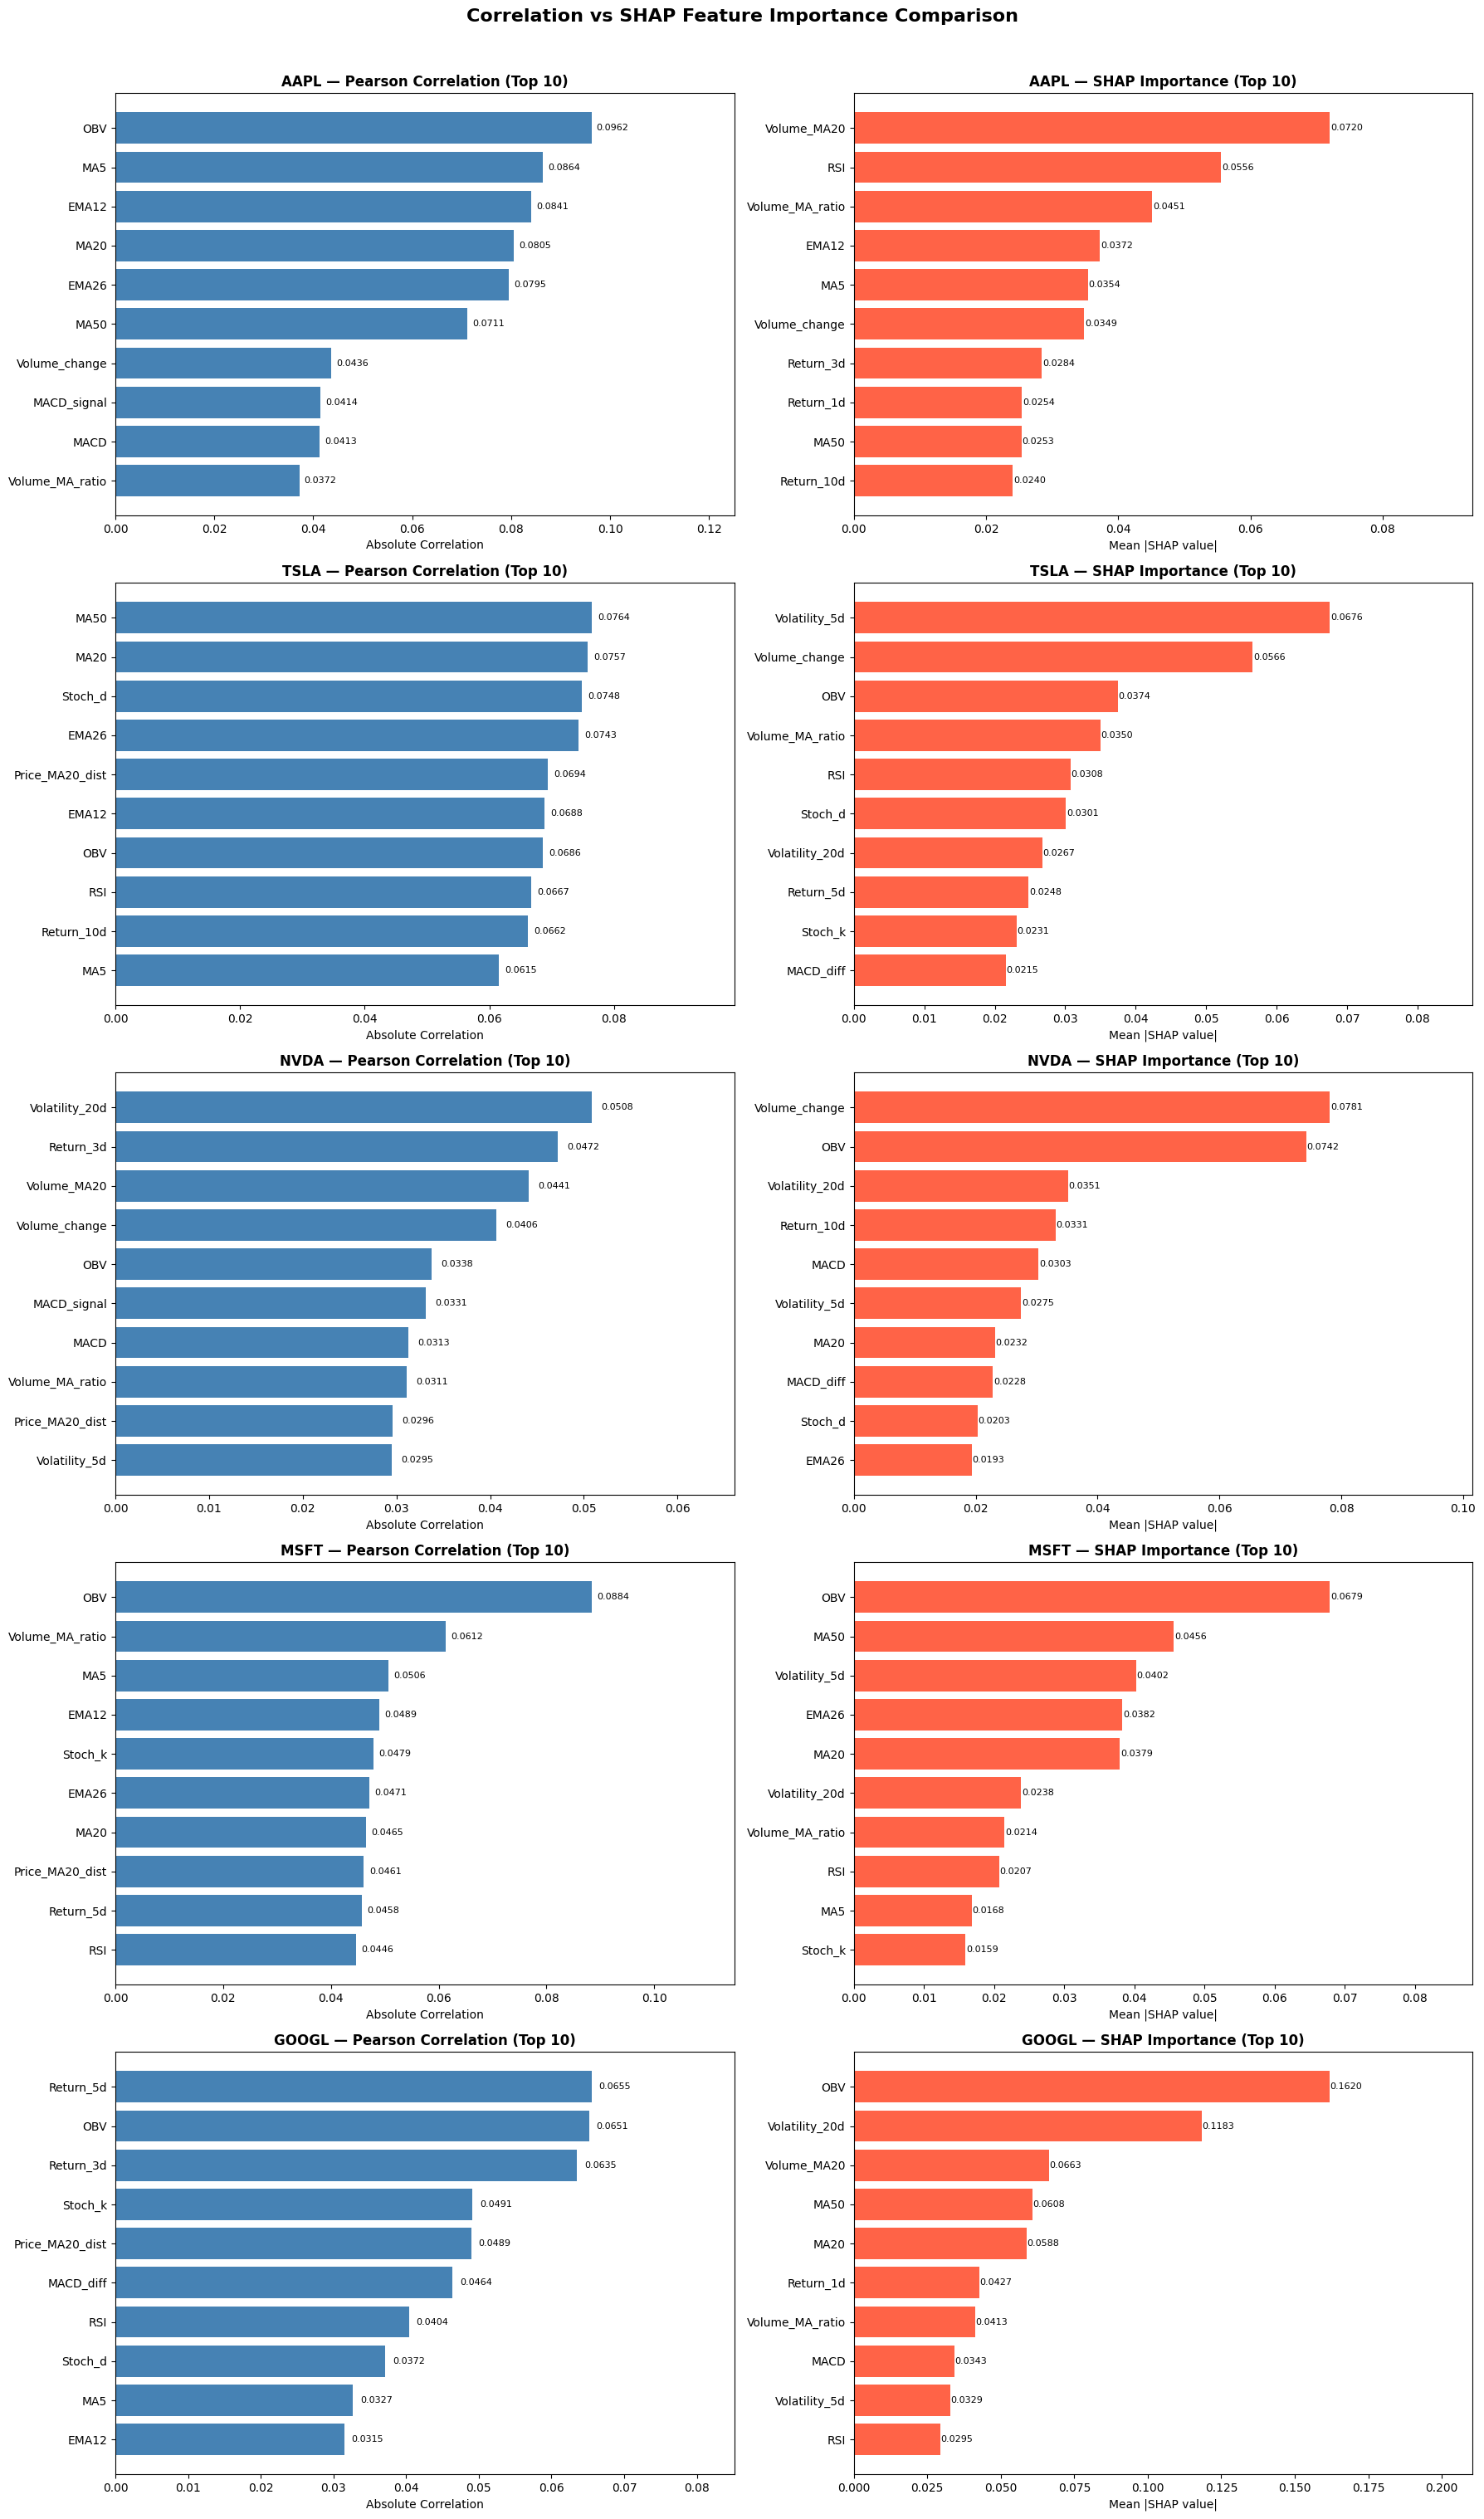

✅ Saved: correlation_vs_shap.png


In [16]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

fig, axes = plt.subplots(5, 2, figsize=(18, 30))
fig.suptitle("Correlation vs SHAP Feature Importance Comparison", fontsize=16, fontweight="bold", y=1.01)

for idx, ticker in enumerate(TICKERS):
    corr_df = results[ticker]["corr_df"].head(10)
    shap_df = results[ticker]["shap_df"].head(10)
    
    # Correlation plot
    ax1 = axes[idx, 0]
    bars1 = ax1.barh(corr_df["Feature"][::-1], corr_df["Correlation"][::-1], color="steelblue")
    ax1.set_title(f"{ticker} — Pearson Correlation (Top 10)", fontweight="bold")
    ax1.set_xlabel("Absolute Correlation")
    ax1.set_xlim(0, corr_df["Correlation"].max() * 1.3)
    for bar, val in zip(bars1, corr_df["Correlation"][::-1]):
        ax1.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=8)
    
    # SHAP plot
    ax2 = axes[idx, 1]
    bars2 = ax2.barh(shap_df["Feature"][::-1], shap_df["SHAP_Importance"][::-1], color="tomato")
    ax2.set_title(f"{ticker} — SHAP Importance (Top 10)", fontweight="bold")
    ax2.set_xlabel("Mean |SHAP value|")
    ax2.set_xlim(0, shap_df["SHAP_Importance"].max() * 1.3)
    for bar, val in zip(bars2, shap_df["SHAP_Importance"][::-1]):
        ax2.text(bar.get_width() + 0.0001, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("correlation_vs_shap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: correlation_vs_shap.png")

In [17]:
def rank_comparison(ticker):
    corr_df = results[ticker]["corr_df"].reset_index(drop=True)
    shap_df = results[ticker]["shap_df"].reset_index(drop=True)
    
    corr_rank = {row["Feature"]: i+1 for i, row in corr_df.iterrows()}
    shap_rank = {row["Feature"]: i+1 for i, row in shap_df.iterrows()}
    
    rows = []
    for feat in FEATURE_COLS:
        cr = corr_rank.get(feat, 999)
        sr = shap_rank.get(feat, 999)
        rows.append({
            "Feature": feat,
            "Corr_Rank": cr,
            "SHAP_Rank": sr,
            "Rank_Diff": abs(cr - sr)
        })
    
    df = pd.DataFrame(rows).sort_values("Rank_Diff", ascending=False)
    return df

print("=" * 55)
for ticker in TICKERS:
    print(f"\n📊 {ticker} — Features ที่ rank ต่างกันมากที่สุด")
    print("=" * 55)
    rank_df = rank_comparison(ticker)
    print(rank_df.head(8).to_string(index=False))
    results[ticker]["rank_df"] = rank_df


📊 AAPL — Features ที่ rank ต่างกันมากที่สุด
        Feature  Corr_Rank  SHAP_Rank  Rank_Diff
          EMA26          5         17         12
           MACD          9         21         12
    Volume_MA20         12          1         11
            RSI         13          2         11
            OBV          1         12         11
      Return_3d         15          7          8
     Return_10d         18         10          8
Volume_MA_ratio         10          3          7

📊 TSLA — Features ที่ rank ต่างกันมากที่สุด
        Feature  Corr_Rank  SHAP_Rank  Rank_Diff
  Volatility_5d         22          1         21
           MA50          1         19         18
  Volume_change         20          2         18
           MA20          2         17         15
Volume_MA_ratio         17          4         13
 Volatility_20d         18          7         11
          EMA12          6         16         10
      Return_1d         21         11         10

📊 NVDA — Features ที่ rank 

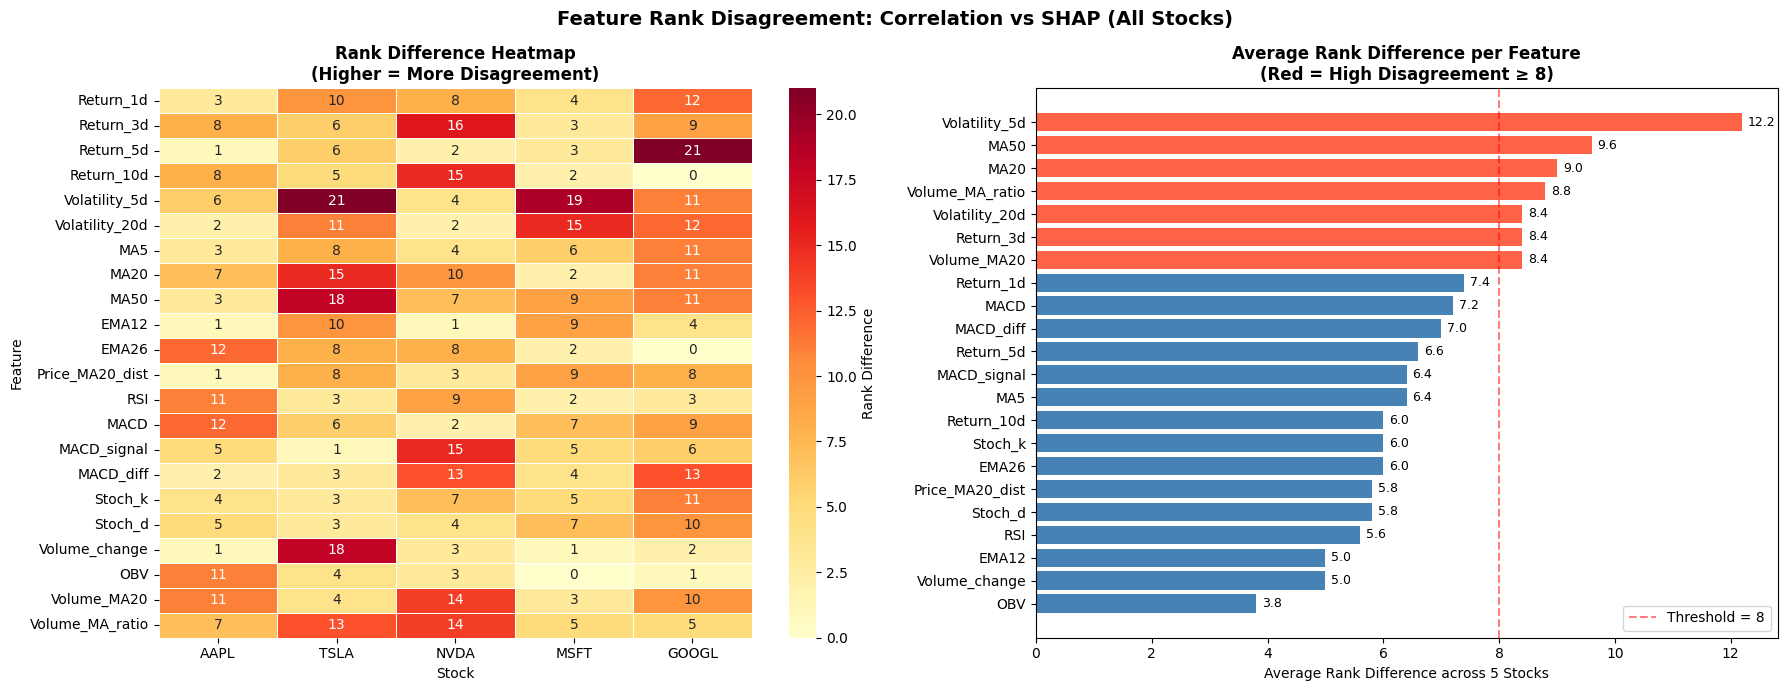

✅ Saved: rank_disagreement_summary.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Feature Rank Disagreement: Correlation vs SHAP (All Stocks)", 
             fontsize=14, fontweight="bold")

# --- Plot 1: Heatmap of Rank Difference ---
rank_diff_matrix = pd.DataFrame(index=FEATURE_COLS)
for ticker in TICKERS:
    rank_df = results[ticker]["rank_df"].set_index("Feature")
    rank_diff_matrix[ticker] = rank_df["Rank_Diff"]

sns.heatmap(rank_diff_matrix, ax=axes[0], cmap="YlOrRd", 
            annot=True, fmt=".0f", linewidths=0.5,
            cbar_kws={"label": "Rank Difference"})
axes[0].set_title("Rank Difference Heatmap\n(Higher = More Disagreement)", fontweight="bold")
axes[0].set_xlabel("Stock")
axes[0].set_ylabel("Feature")

# --- Plot 2: Average Rank Difference per Feature ---
rank_diff_matrix["Avg_Diff"] = rank_diff_matrix[TICKERS].mean(axis=1)
avg_sorted = rank_diff_matrix["Avg_Diff"].sort_values(ascending=False)

colors = ["tomato" if v >= 8 else "steelblue" for v in avg_sorted.values]
bars = axes[1].barh(avg_sorted.index[::-1], avg_sorted.values[::-1], color=colors[::-1])
axes[1].set_title("Average Rank Difference per Feature\n(Red = High Disagreement ≥ 8)", fontweight="bold")
axes[1].set_xlabel("Average Rank Difference across 5 Stocks")
axes[1].axvline(x=8, color="red", linestyle="--", alpha=0.5, label="Threshold = 8")
axes[1].legend()

for bar, val in zip(bars, avg_sorted.values[::-1]):
    axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f"{val:.1f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("rank_disagreement_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: rank_disagreement_summary.png")

In [19]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def get_top_features(ticker, method="corr", top_k=10):
    if method == "corr":
        return results[ticker]["corr_df"]["Feature"].head(top_k).tolist()
    else:
        return results[ticker]["shap_df"]["Feature"].head(top_k).tolist()

def prepare_data_subset(df, feature_cols, seq_len=20, test_size=0.2):
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    scaled = scaler.fit_transform(df[feature_cols])
    target = df["Target"].values
    
    X, y = [], []
    for i in range(seq_len, len(scaled)):
        X.append(scaled[i-seq_len:i])
        y.append(target[i])
    
    X, y = np.array(X), np.array(y)
    split = int(len(X) * (1 - test_size))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    
    train_loader = DataLoader(StockDataset(X_train, y_train), batch_size=32, shuffle=True)
    test_loader = DataLoader(StockDataset(X_test, y_test), batch_size=32, shuffle=False)
    
    return train_loader, test_loader, X_test, y_test

def train_and_evaluate(ticker, feature_cols, epochs=50):
    train_loader, test_loader, X_test, y_test = prepare_data_subset(
        featured_data[ticker], feature_cols
    )
    
    model = LSTMModel(input_size=len(feature_cols)).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
    
    best_acc = 0
    best_state = None
    
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
        
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                pred = model(X_batch).argmax(dim=1)
                correct += (pred == y_batch).sum().item()
                total += len(y_batch)
        acc = correct / total
        if acc > best_acc:
            best_acc = acc
            best_state = model.state_dict().copy()
        scheduler.step()
    
    model.load_state_dict(best_state)
    model.eval()
    
    preds, probs_list = [], []
    with torch.no_grad():
        for i in range(0, len(X_test), 32):
            batch = torch.tensor(X_test[i:i+32], dtype=torch.float32).to(device)
            out = model(batch)
            preds.extend(out.argmax(dim=1).cpu().numpy())
            probs_list.extend(torch.softmax(out, dim=1)[:, 1].cpu().numpy())
    
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, probs_list)
    return acc, f1, auc

# รัน experiment ทั้ง 3 แบบ
experiment_results = []

for ticker in TICKERS:
    print(f"=== {ticker} ===")
    
    # Baseline (all features)
    base_acc = results[ticker]["baseline_acc"]
    base_f1 = results[ticker]["baseline_f1"]
    
    # Correlation top-10
    corr_feats = get_top_features(ticker, "corr", 10)
    corr_acc, corr_f1, corr_auc = train_and_evaluate(ticker, corr_feats)
    print(f"  Corr top-10:  Acc={corr_acc:.4f} F1={corr_f1:.4f} AUC={corr_auc:.4f}")
    
    # SHAP top-10
    shap_feats = get_top_features(ticker, "shap", 10)
    shap_acc, shap_f1, shap_auc = train_and_evaluate(ticker, shap_feats)
    print(f"  SHAP top-10:  Acc={shap_acc:.4f} F1={shap_f1:.4f} AUC={shap_auc:.4f}")
    
    experiment_results.append({
        "Ticker": ticker,
        "Baseline_Acc": base_acc,
        "Corr_Acc": corr_acc, "Corr_F1": corr_f1, "Corr_AUC": corr_auc,
        "SHAP_Acc": shap_acc, "SHAP_F1": shap_f1, "SHAP_AUC": shap_auc
    })

exp_df = pd.DataFrame(experiment_results)
print("\n=== Summary ===")
print(exp_df.to_string(index=False))

=== AAPL ===
  Corr top-10:  Acc=0.4606 F1=0.3628 AUC=0.5510
  SHAP top-10:  Acc=0.4803 F1=0.4310 AUC=0.5110
=== TSLA ===
  Corr top-10:  Acc=0.5276 F1=0.4595 AUC=0.5121
  SHAP top-10:  Acc=0.4567 F1=0.5274 AUC=0.4691
=== NVDA ===
  Corr top-10:  Acc=0.5039 F1=0.5909 AUC=0.4733
  SHAP top-10:  Acc=0.5000 F1=0.3553 AUC=0.5360
=== MSFT ===
  Corr top-10:  Acc=0.5079 F1=0.5455 AUC=0.5330
  SHAP top-10:  Acc=0.5079 F1=0.4856 AUC=0.5131
=== GOOGL ===
  Corr top-10:  Acc=0.4921 F1=0.3768 AUC=0.5160
  SHAP top-10:  Acc=0.4488 F1=0.2857 AUC=0.4575

=== Summary ===
Ticker  Baseline_Acc  Corr_Acc  Corr_F1  Corr_AUC  SHAP_Acc  SHAP_F1  SHAP_AUC
  AAPL      0.444882  0.460630 0.362791  0.550962  0.480315 0.431034  0.511026
  TSLA      0.519685  0.527559 0.459459  0.512091  0.456693 0.527397  0.469122
  NVDA      0.488189  0.503937 0.590909  0.473321  0.500000 0.355330  0.536007
  MSFT      0.515748  0.507874 0.545455  0.532971  0.507874 0.485597  0.513070
 GOOGL      0.484252  0.492126 0.376812  0

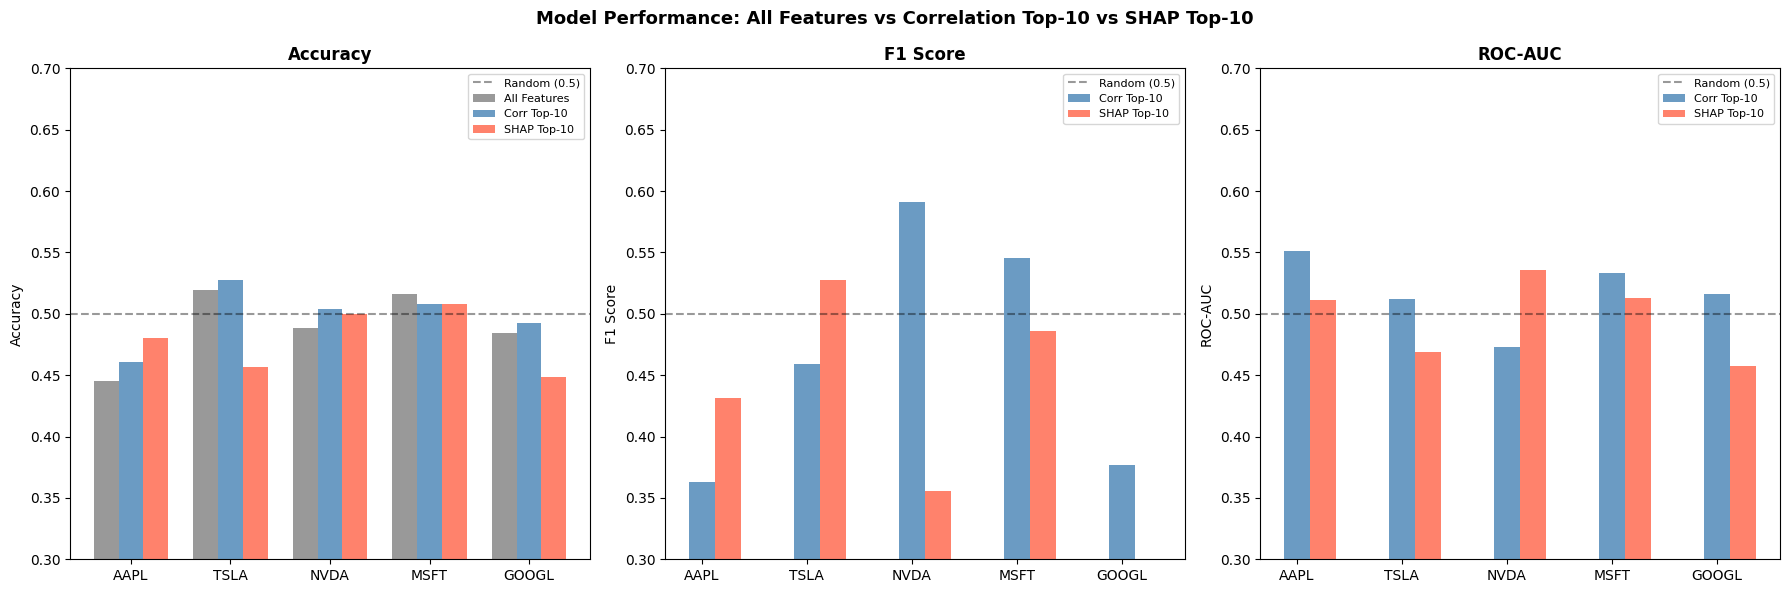


=== Win/Loss Summary ===
Ticker    SHAP_Acc > Corr_Acc  SHAP_AUC > Corr_AUC
--------------------------------------------------
AAPL                   ✅ SHAP               ❌ Corr
TSLA                   ❌ Corr               ❌ Corr
NVDA                   ❌ Corr               ✅ SHAP
MSFT                   ❌ Corr               ❌ Corr
GOOGL                  ❌ Corr               ❌ Corr
--------------------------------------------------
SHAP wins 1/5 stocks          1/5 stocks


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Model Performance: All Features vs Correlation Top-10 vs SHAP Top-10", 
             fontsize=13, fontweight="bold")

metrics = [("Acc", "Accuracy"), ("F1", "F1 Score"), ("AUC", "ROC-AUC")]

for ax, (metric, title) in zip(axes, metrics):
    x = np.arange(len(TICKERS))
    width = 0.25
    
    if metric == "Acc":
        baseline_vals = [results[t]["baseline_acc"] for t in TICKERS]
    else:
        baseline_vals = None
    
    corr_vals = exp_df[f"Corr_{metric}"].values
    shap_vals = exp_df[f"SHAP_{metric}"].values
    
    if baseline_vals:
        ax.bar(x - width, baseline_vals, width, label="All Features", color="gray", alpha=0.8)
    ax.bar(x, corr_vals, width, label="Corr Top-10", color="steelblue", alpha=0.8)
    ax.bar(x + width, shap_vals, width, label="SHAP Top-10", color="tomato", alpha=0.8)
    
    ax.set_title(title, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(TICKERS)
    ax.set_ylim(0.3, 0.7)
    ax.axhline(y=0.5, color="black", linestyle="--", alpha=0.4, label="Random (0.5)")
    ax.legend(fontsize=8)
    ax.set_ylabel(title)

plt.tight_layout()
plt.savefig("experiment_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary table
print("\n=== Win/Loss Summary ===")
print(f"{'Ticker':<8} {'SHAP_Acc > Corr_Acc':>20} {'SHAP_AUC > Corr_AUC':>20}")
print("-" * 50)
shap_win_acc, shap_win_auc = 0, 0
for _, row in exp_df.iterrows():
    acc_win = "✅ SHAP" if row["SHAP_Acc"] > row["Corr_Acc"] else "❌ Corr"
    auc_win = "✅ SHAP" if row["SHAP_AUC"] > row["Corr_AUC"] else "❌ Corr"
    if row["SHAP_Acc"] > row["Corr_Acc"]: shap_win_acc += 1
    if row["SHAP_AUC"] > row["Corr_AUC"]: shap_win_auc += 1
    print(f"{row['Ticker']:<8} {acc_win:>20} {auc_win:>20}")
print("-" * 50)
print(f"{'SHAP wins':<8} {shap_win_acc}/5 stocks {' ':>8} {shap_win_auc}/5 stocks")

  0%|          | 0/5 [00:00<?, ?it/s]

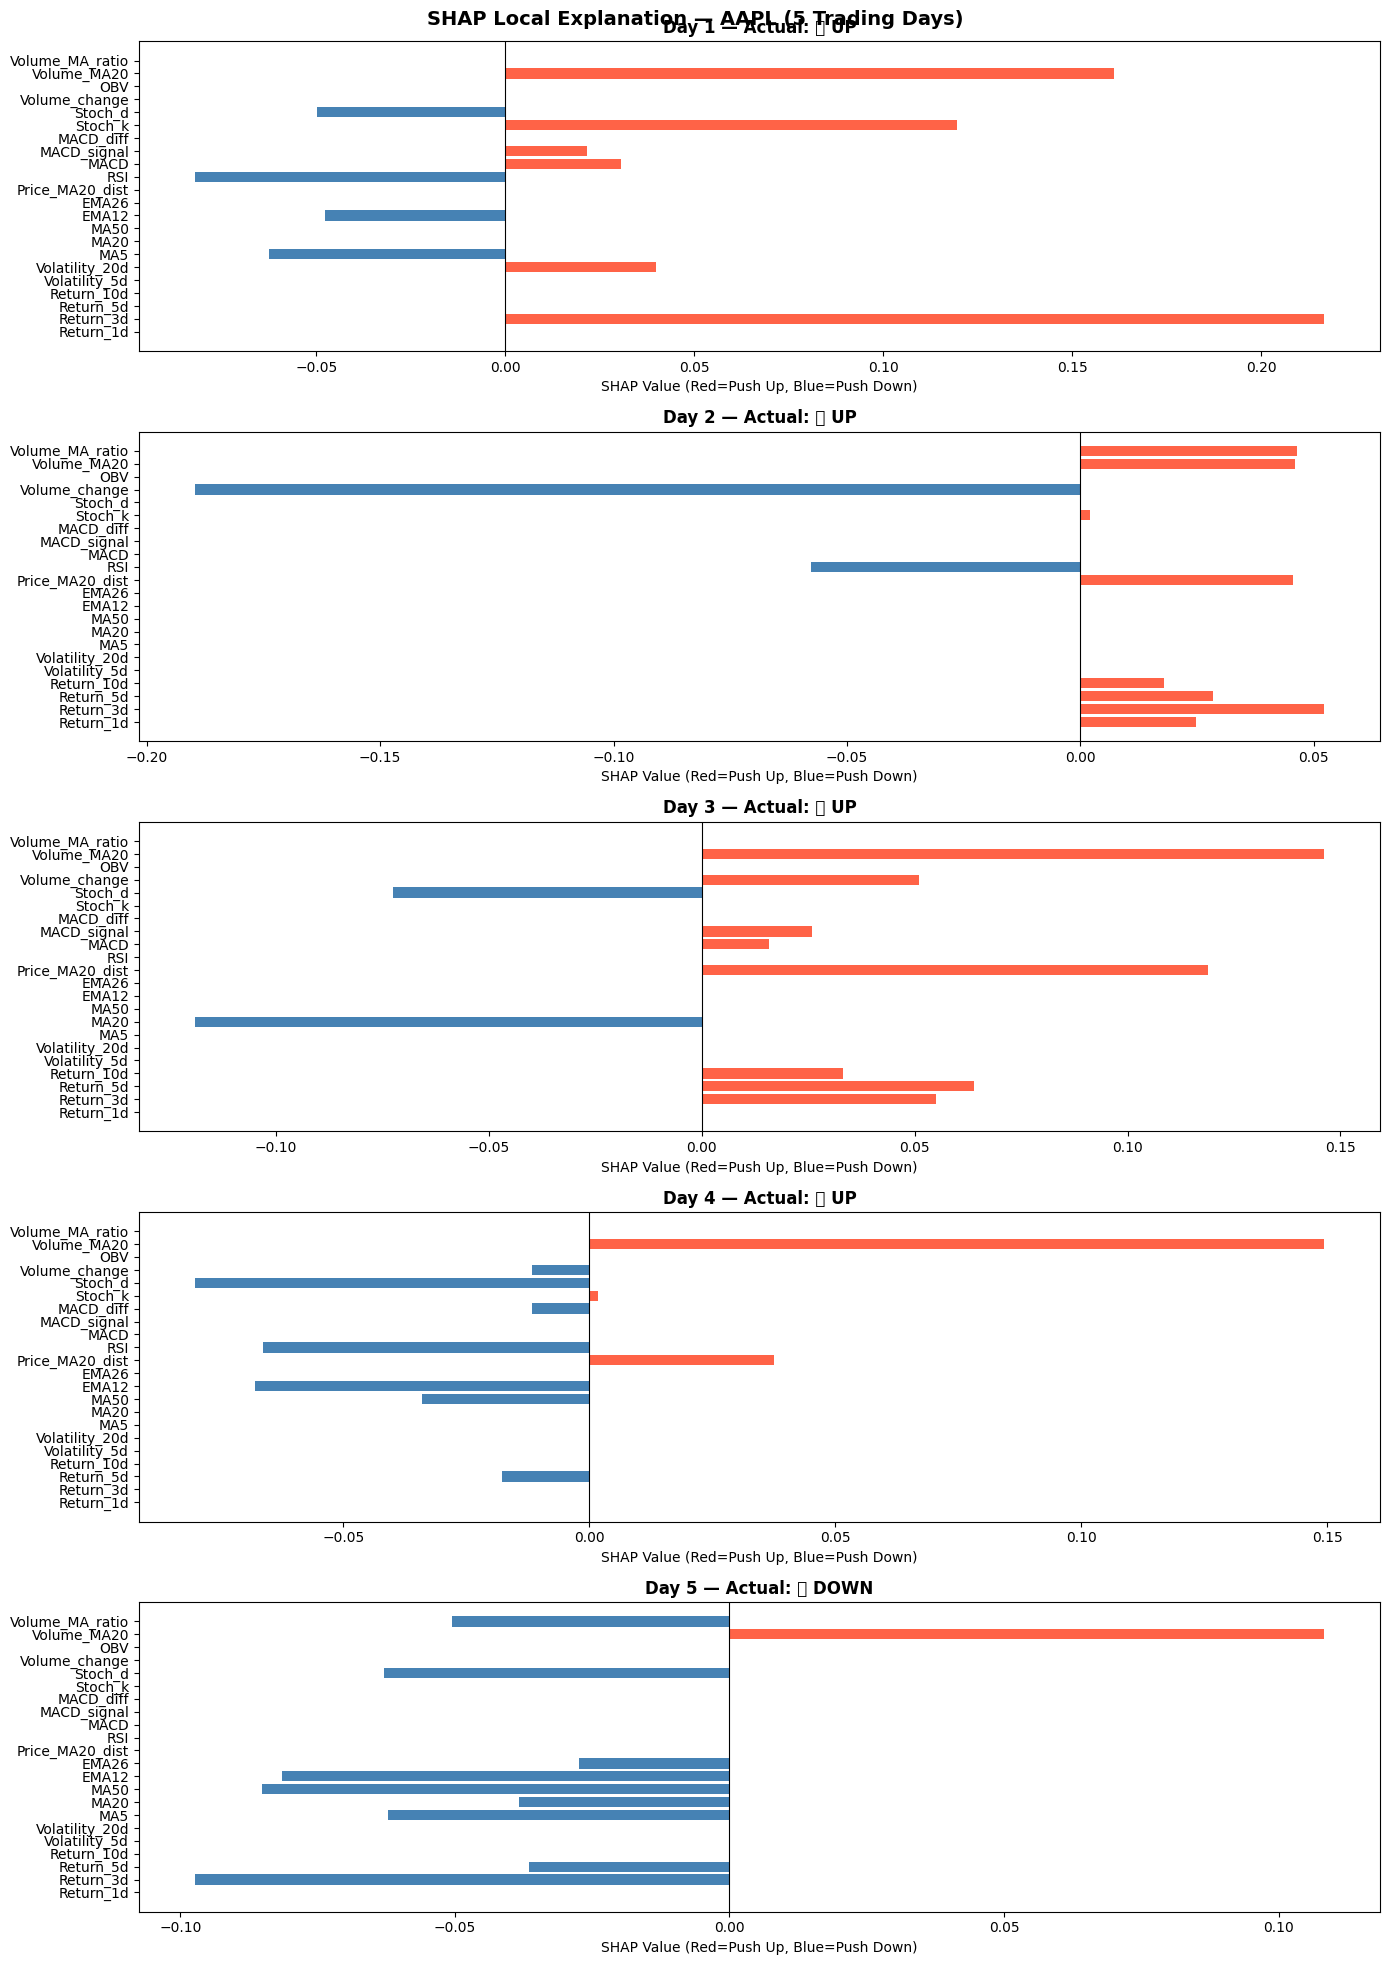

✅ Saved: shap_local_explanation.png


In [21]:
# SHAP Local Explanation — อธิบายการทำนายรายวัน
ticker = "AAPL"
X_test_flat = prepared_data[ticker]["X_test"][:, -1, :]
X_train_flat = prepared_data[ticker]["X_train"][:, -1, :]

background = shap.kmeans(X_train_flat, 20)

def predict_fn_local(X_np):
    model_cpu = models[ticker].cpu()
    model_cpu.eval()
    X_seq = np.stack([X_np] * SEQUENCE_LEN, axis=1)
    with torch.no_grad():
        X_tensor = torch.tensor(X_seq, dtype=torch.float32)
        out = model_cpu(X_tensor)
        probs = torch.softmax(out, dim=1).numpy()
    return probs

explainer = shap.KernelExplainer(predict_fn_local, background)

# อธิบายแค่ 5 วัน
n_explain = 5
shap_local = explainer.shap_values(X_test_flat[:n_explain], nsamples=100)
# shape: (5, 22, 2)

fig, axes = plt.subplots(n_explain, 1, figsize=(14, 4 * n_explain))
fig.suptitle(f"SHAP Local Explanation — {ticker} (5 Trading Days)", 
             fontsize=14, fontweight="bold")

y_test = prepared_data[ticker]["y_test"]

for i in range(n_explain):
    sv = shap_local[i, :, 1]  # SHAP สำหรับ class 1 (ขึ้น)
    actual = "📈 UP" if y_test[i] == 1 else "📉 DOWN"
    
    colors = ["tomato" if v > 0 else "steelblue" for v in sv]
    axes[i].barh(FEATURE_COLS, sv, color=colors)
    axes[i].axvline(x=0, color="black", linewidth=0.8)
    axes[i].set_title(f"Day {i+1} — Actual: {actual}", fontweight="bold")
    axes[i].set_xlabel("SHAP Value (Red=Push Up, Blue=Push Down)")

plt.tight_layout()
plt.savefig("shap_local_explanation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: shap_local_explanation.png")

# คืน model กลับ GPU
models[ticker] = models[ticker].to(device)

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import shap

baseline_results = {}

for ticker in TICKERS:
    print(f"=== {ticker} ===")
    
    X_train = prepared_data[ticker]["X_train"][:, -1, :]
    X_test = prepared_data[ticker]["X_test"][:, -1, :]
    y_train = prepared_data[ticker]["y_train"]
    y_test = prepared_data[ticker]["y_test"]
    
    # --- Random Forest ---
    rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)
    rf_prob = rf.predict_proba(X_test)[:, 1]
    rf_acc = accuracy_score(y_test, rf_pred)
    rf_f1 = f1_score(y_test, rf_pred)
    rf_auc = roc_auc_score(y_test, rf_prob)
    
    # SHAP for Random Forest
    rf_explainer = shap.TreeExplainer(rf)
    rf_shap = rf_explainer.shap_values(X_test[:100])
    # shape: (100, 22, 2) → เอา class 1
    rf_shap_imp = np.abs(rf_shap[:, :, 1]).mean(axis=0)
    
    rf_shap_df = pd.DataFrame({
        "Feature": FEATURE_COLS,
        "RF_SHAP": rf_shap_imp
    }).sort_values("RF_SHAP", ascending=False).reset_index(drop=True)
    
    # --- Logistic Regression ---
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train, y_train)
    lr_pred = lr.predict(X_test)
    lr_prob = lr.predict_proba(X_test)[:, 1]
    lr_acc = accuracy_score(y_test, lr_pred)
    lr_f1 = f1_score(y_test, lr_pred)
    lr_auc = roc_auc_score(y_test, lr_prob)
    
    # SHAP for Logistic Regression
    lr_explainer = shap.LinearExplainer(lr, X_train)
    lr_shap = lr_explainer.shap_values(X_test[:100])
    lr_shap_imp = np.abs(lr_shap).mean(axis=0)
    
    lr_shap_df = pd.DataFrame({
        "Feature": FEATURE_COLS,
        "LR_SHAP": lr_shap_imp
    }).sort_values("LR_SHAP", ascending=False).reset_index(drop=True)
    
    baseline_results[ticker] = {
        "rf": rf, "lr": lr,
        "rf_acc": rf_acc, "rf_f1": rf_f1, "rf_auc": rf_auc,
        "lr_acc": lr_acc, "lr_f1": lr_f1, "lr_auc": lr_auc,
        "rf_shap_df": rf_shap_df,
        "lr_shap_df": lr_shap_df
    }
    
    print(f"  Random Forest: Acc={rf_acc:.4f} F1={rf_f1:.4f} AUC={rf_auc:.4f}")
    print(f"  Logistic Reg:  Acc={lr_acc:.4f} F1={lr_f1:.4f} AUC={lr_auc:.4f}")
    print(f"  RF Top-5 SHAP:  {rf_shap_df['Feature'].head(5).tolist()}")
    print(f"  LR Top-5 SHAP:  {lr_shap_df['Feature'].head(5).tolist()}\n")

=== AAPL ===
  Random Forest: Acc=0.4331 F1=0.0886 AUC=0.5375
  Logistic Reg:  Acc=0.4291 F1=0.1420 AUC=0.5548
  RF Top-5 SHAP:  ['EMA26', 'EMA12', 'MA20', 'MA5', 'OBV']
  LR Top-5 SHAP:  ['Price_MA20_dist', 'MA20', 'MA5', 'RSI', 'OBV']

=== TSLA ===
  Random Forest: Acc=0.5591 F1=0.4955 AUC=0.5271
  Logistic Reg:  Acc=0.5591 F1=0.5130 AUC=0.5809
  RF Top-5 SHAP:  ['OBV', 'Volume_MA20', 'Volume_MA_ratio', 'MACD_diff', 'Volume_change']
  LR Top-5 SHAP:  ['Stoch_d', 'Stoch_k', 'RSI', 'MA5', 'Volume_MA_ratio']

=== NVDA ===
  Random Forest: Acc=0.5433 F1=0.5538 AUC=0.5617
  Logistic Reg:  Acc=0.5118 F1=0.6754 AUC=0.4647
  RF Top-5 SHAP:  ['OBV', 'MACD', 'Return_1d', 'Volume_change', 'MACD_diff']
  LR Top-5 SHAP:  ['MACD_diff', 'OBV', 'MA5', 'MA50', 'MA20']

=== MSFT ===
  Random Forest: Acc=0.4646 F1=0.3524 AUC=0.4847
  Logistic Reg:  Acc=0.4685 F1=0.3147 AUC=0.5637
  RF Top-5 SHAP:  ['Volume_MA20', 'MA5', 'OBV', 'MA20', 'Return_1d']
  LR Top-5 SHAP:  ['OBV', 'MACD_diff', 'Price_MA20_dist

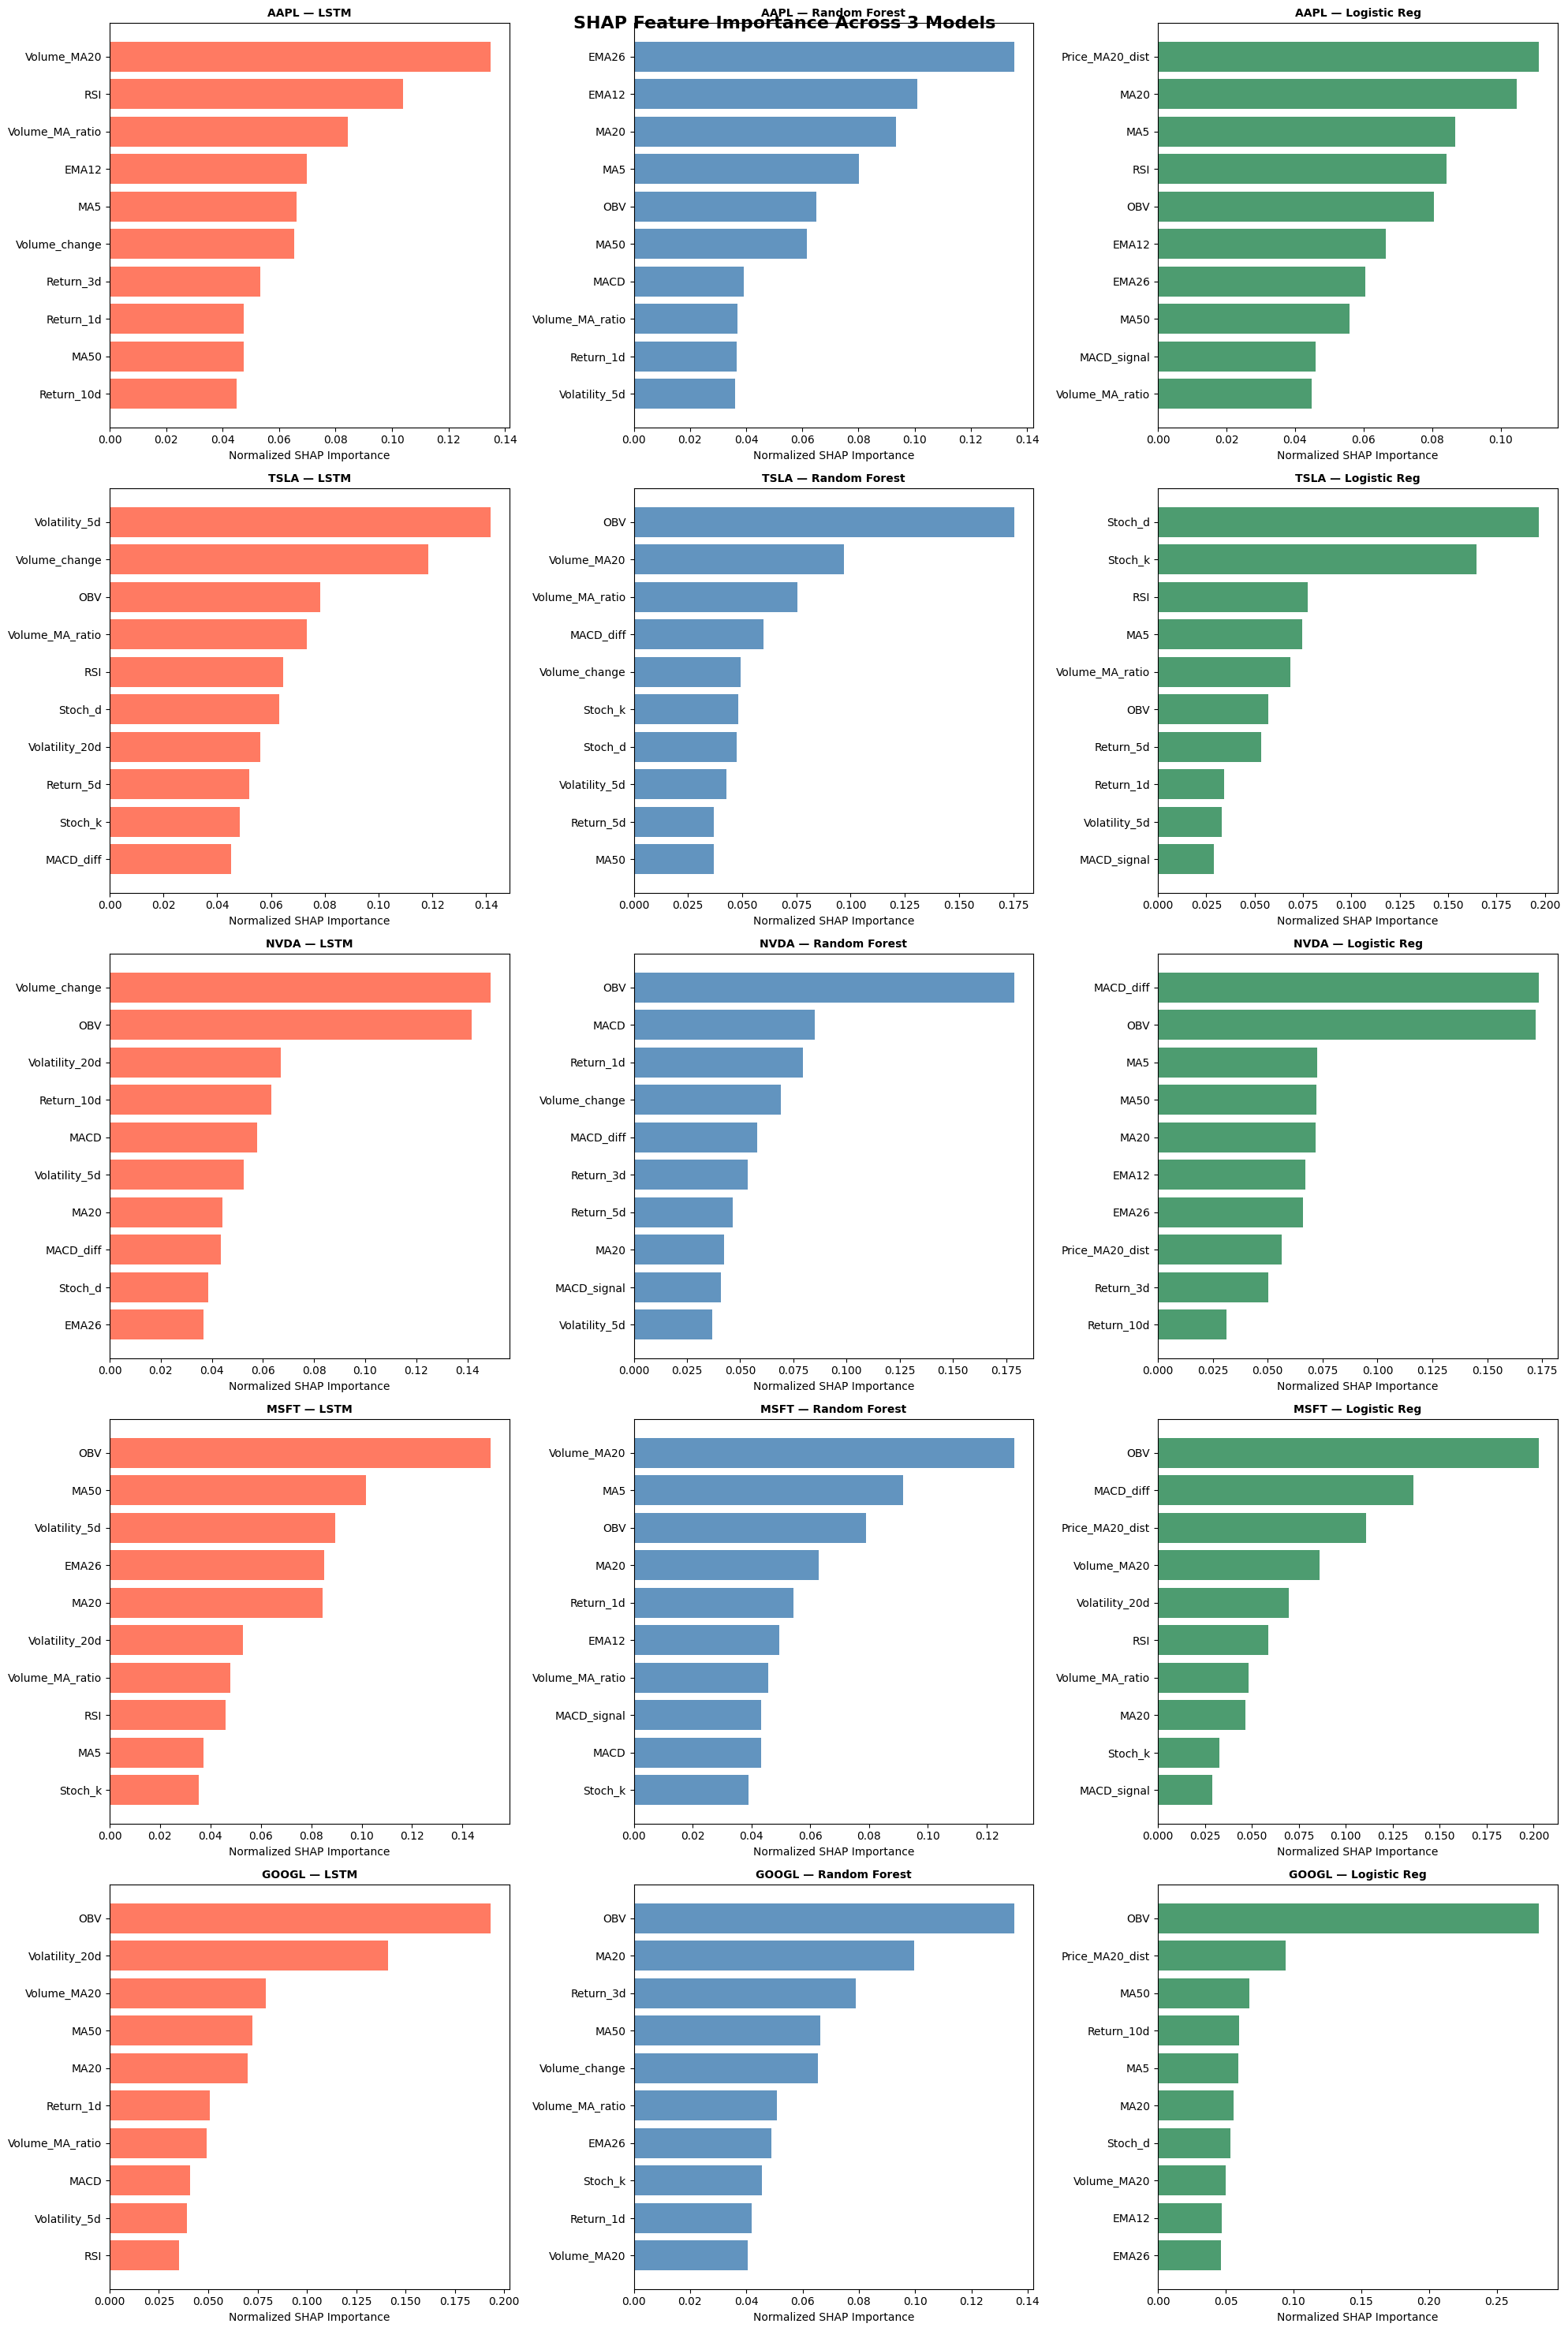

✅ Saved: shap_cross_model.png

=== OBV Rank across models ===
Ticker       LSTM       RF       LR
-----------------------------------
AAPL           12        5        5
TSLA            3        1        6
NVDA            2        1        2
MSFT            1        3        1
GOOGL           1        1        1


In [25]:
fig, axes = plt.subplots(5, 3, figsize=(20, 30))
fig.suptitle("SHAP Feature Importance Across 3 Models", fontsize=16, fontweight="bold")

for idx, ticker in enumerate(TICKERS):
    lstm_shap = results[ticker]["shap_df"].set_index("Feature")["SHAP_Importance"]
    rf_shap = baseline_results[ticker]["rf_shap_df"].set_index("Feature")["RF_SHAP"]
    lr_shap = baseline_results[ticker]["lr_shap_df"].set_index("Feature")["LR_SHAP"]
    
    # Normalize แต่ละ model ให้ sum=1 เพื่อเปรียบเทียบได้
    lstm_norm = lstm_shap / lstm_shap.sum()
    rf_norm = rf_shap / rf_shap.sum()
    lr_norm = lr_shap / lr_shap.sum()
    
    for ax, (shap_series, model_name, color) in zip(
        axes[idx],
        [(lstm_norm, "LSTM", "tomato"), (rf_norm, "Random Forest", "steelblue"), (lr_norm, "Logistic Reg", "seagreen")]
    ):
        top10 = shap_series.sort_values(ascending=False).head(10)
        ax.barh(top10.index[::-1], top10.values[::-1], color=color, alpha=0.85)
        ax.set_title(f"{ticker} — {model_name}", fontweight="bold", fontsize=10)
        ax.set_xlabel("Normalized SHAP Importance")

plt.tight_layout()
plt.savefig("shap_cross_model.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: shap_cross_model.png")

# Cross-model consistency check
print("\n=== OBV Rank across models ===")
print(f"{'Ticker':<8} {'LSTM':>8} {'RF':>8} {'LR':>8}")
print("-" * 35)
for ticker in TICKERS:
    lstm_rank = results[ticker]["shap_df"]["Feature"].tolist().index("OBV") + 1
    rf_rank = baseline_results[ticker]["rf_shap_df"]["Feature"].tolist().index("OBV") + 1
    lr_rank = baseline_results[ticker]["lr_shap_df"]["Feature"].tolist().index("OBV") + 1
    print(f"{ticker:<8} {lstm_rank:>8} {rf_rank:>8} {lr_rank:>8}")

In [28]:
# ดึง Close ของ VIX จาก MultiIndex
vix_close = vix_raw[("Close", "^VIX")]
vix_df = pd.DataFrame({"VIX": vix_close})
vix_df["VIX_change"] = vix_df["VIX"].pct_change()
vix_df["VIX_MA5"] = vix_df["VIX"].rolling(5).mean()
vix_df["VIX_MA20"] = vix_df["VIX"].rolling(20).mean()
vix_df["Fear_level"] = pd.cut(vix_df["VIX"],
                               bins=[0, 15, 20, 30, 100],
                               labels=[0, 1, 2, 3]).astype(float)
vix_df = vix_df.dropna()
print(f"VIX data: {len(vix_df)} rows")
print(vix_df.head())

VIX data: 1316 rows
                  VIX  VIX_change  VIX_MA5  VIX_MA20  Fear_level
Date                                                            
2020-01-30  15.490000   -0.054912   16.190   13.6960         1.0
2020-01-31  18.840000    0.216269   17.046   14.0145         1.0
2020-02-03  17.969999   -0.046178   16.994   14.2120         1.0
2020-02-04  16.049999   -0.106845   16.948   14.3220         1.0
2020-02-05  15.150000   -0.056075   16.700   14.3900         1.0


In [29]:
VIX_FEATURES = ["VIX", "VIX_change", "VIX_MA5", "VIX_MA20", "Fear_level"]
FEATURE_COLS_VIX = FEATURE_COLS + VIX_FEATURES

def create_features_with_vix(df, vix_df):
    merged = df.join(vix_df[VIX_FEATURES], how="inner")
    return merged

# สร้าง featured data ที่รวม VIX
featured_data_vix = {}
for ticker in TICKERS:
    df = create_features(stock_data[ticker])
    df_vix = create_features_with_vix(df, vix_df)
    featured_data_vix[ticker] = df_vix.dropna()
    print(f"{ticker}: {len(featured_data_vix[ticker])} rows, {len(featured_data_vix[ticker].columns)} columns")

AAPL: 1286 rows, 33 columns
TSLA: 1286 rows, 33 columns
NVDA: 1286 rows, 33 columns
MSFT: 1286 rows, 33 columns
GOOGL: 1286 rows, 33 columns


In [31]:
def train_model_v2(ticker, train_loader, test_loader, input_size, epochs=50):
    model = LSTMModel(input_size=input_size).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
    
    best_acc = 0
    best_model_state = None
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                pred = model(X_batch).argmax(dim=1)
                correct += (pred == y_batch).sum().item()
                total += len(y_batch)
        
        acc = correct / total
        if acc > best_acc:
            best_acc = acc
            best_model_state = model.state_dict().copy()
        
        if (epoch + 1) % 10 == 0:
            print(f"{ticker} | Epoch {epoch+1}/{epochs} | Loss: {train_loss/len(train_loader):.4f} | Acc: {acc:.4f}")
        
        scheduler.step()
    
    model.load_state_dict(best_model_state)
    print(f"{ticker} | Best Accuracy: {best_acc:.4f}\n")
    return model

# Train LSTM พร้อม VIX
print("=== Training with VIX Sentiment ===")
models_vix = {}
for ticker in TICKERS:
    print(f"=== Training {ticker} ===")
    models_vix[ticker] = train_model_v2(
        ticker,
        prepared_data_vix[ticker]["train_loader"],
        prepared_data_vix[ticker]["test_loader"],
        input_size=len(FEATURE_COLS_VIX),
        epochs=50
    )

=== Training with VIX Sentiment ===
=== Training AAPL ===
AAPL | Epoch 10/50 | Loss: 0.6854 | Acc: 0.4213
AAPL | Epoch 20/50 | Loss: 0.6482 | Acc: 0.4843
AAPL | Epoch 30/50 | Loss: 0.6032 | Acc: 0.4764
AAPL | Epoch 40/50 | Loss: 0.5657 | Acc: 0.4764
AAPL | Epoch 50/50 | Loss: 0.5251 | Acc: 0.4882
AAPL | Best Accuracy: 0.5000

=== Training TSLA ===
TSLA | Epoch 10/50 | Loss: 0.6747 | Acc: 0.5276
TSLA | Epoch 20/50 | Loss: 0.6385 | Acc: 0.4921
TSLA | Epoch 30/50 | Loss: 0.5959 | Acc: 0.5118
TSLA | Epoch 40/50 | Loss: 0.5745 | Acc: 0.5039
TSLA | Epoch 50/50 | Loss: 0.5463 | Acc: 0.5236
TSLA | Best Accuracy: 0.5630

=== Training NVDA ===
NVDA | Epoch 10/50 | Loss: 0.6765 | Acc: 0.5236
NVDA | Epoch 20/50 | Loss: 0.6225 | Acc: 0.5039
NVDA | Epoch 30/50 | Loss: 0.5541 | Acc: 0.5236
NVDA | Epoch 40/50 | Loss: 0.5077 | Acc: 0.5315
NVDA | Epoch 50/50 | Loss: 0.4653 | Acc: 0.5630
NVDA | Best Accuracy: 0.5630

=== Training MSFT ===
MSFT | Epoch 10/50 | Loss: 0.6762 | Acc: 0.5236
MSFT | Epoch 20/50

In [32]:
# เปรียบเทียบ Accuracy ก่อนและหลังเพิ่ม VIX
print("=== Accuracy Comparison: Without vs With VIX ===")
print(f"{'Ticker':<8} {'Without VIX':>12} {'With VIX':>12} {'Diff':>8}")
print("-" * 45)

vix_comparison = []
for ticker in TICKERS:
    acc_before = results[ticker]["baseline_acc"]
    
    # วัด accuracy ของ model VIX
    models_vix[ticker].eval()
    preds = []
    y_test = prepared_data_vix[ticker]["y_test"]
    X_test = prepared_data_vix[ticker]["X_test"]
    with torch.no_grad():
        for i in range(0, len(X_test), 32):
            batch = torch.tensor(X_test[i:i+32], dtype=torch.float32).to(device)
            out = models_vix[ticker](batch)
            preds.extend(out.argmax(dim=1).cpu().numpy())
    
    acc_after = accuracy_score(y_test, preds)
    diff = acc_after - acc_before
    symbol = "✅" if diff > 0 else "❌"
    print(f"{ticker:<8} {acc_before:>12.4f} {acc_after:>12.4f} {symbol} {diff:>+.4f}")
    vix_comparison.append({"Ticker": ticker, "Without_VIX": acc_before, "With_VIX": acc_after, "Diff": diff})

# SHAP ของ VIX features
print("\n=== SHAP Importance of VIX Features ===")
print(f"{'Ticker':<8} {'VIX':>8} {'VIX_chg':>10} {'VIX_MA5':>10} {'VIX_MA20':>10} {'Fear':>8}")
print("-" * 55)

for ticker in TICKERS:
    X_train_flat = prepared_data_vix[ticker]["X_train"][:, -1, :]
    X_test_flat = prepared_data_vix[ticker]["X_test"][:, -1, :]
    
    background = shap.kmeans(X_train_flat, 20)
    
    def predict_fn_vix(X_np):
        model_cpu = models_vix[ticker].cpu()
        model_cpu.eval()
        X_seq = np.stack([X_np] * SEQUENCE_LEN, axis=1)
        with torch.no_grad():
            X_tensor = torch.tensor(X_seq, dtype=torch.float32)
            out = model_cpu(X_tensor)
            return torch.softmax(out, dim=1).numpy()
    
    explainer = shap.KernelExplainer(predict_fn_vix, background)
    shap_vals = explainer.shap_values(X_test_flat[:30], nsamples=100)
    # shape: (30, 27, 2)
    sv = np.abs(shap_vals[:, :, 1]).mean(axis=0)
    
    # เอาแค่ VIX features (index 22-26)
    vix_imp = sv[22:]
    print(f"{ticker:<8} {vix_imp[0]:>8.4f} {vix_imp[1]:>10.4f} {vix_imp[2]:>10.4f} {vix_imp[3]:>10.4f} {vix_imp[4]:>8.4f}")
    
    # คืน model กลับ GPU
    models_vix[ticker] = models_vix[ticker].to(device)

print("\n✅ Done!")

=== Accuracy Comparison: Without vs With VIX ===
Ticker    Without VIX     With VIX     Diff
---------------------------------------------
AAPL           0.4449       0.4882 ✅ +0.0433
TSLA           0.5197       0.5236 ✅ +0.0039
NVDA           0.4882       0.5630 ✅ +0.0748
MSFT           0.5157       0.5000 ❌ -0.0157
GOOGL          0.4843       0.5354 ✅ +0.0512

=== SHAP Importance of VIX Features ===
Ticker        VIX    VIX_chg    VIX_MA5   VIX_MA20     Fear
-------------------------------------------------------


  0%|          | 0/30 [00:00<?, ?it/s]

AAPL       0.0140     0.0181     0.0074     0.0065   0.0281


  0%|          | 0/30 [00:00<?, ?it/s]

TSLA       0.0081     0.0252     0.0439     0.0060   0.0143


...

NVDA       0.0051     0.0423     0.0042     0.0074   0.0223


  0%|          | 0/30 [00:00<?, ?it/s]

MSFT       0.0020     0.0309     0.0077     0.0176   0.0209


  0%|          | 0/30 [00:00<?, ?it/s]

GOOGL      0.0064     0.0228     0.0018     0.0261   0.0063

✅ Done!


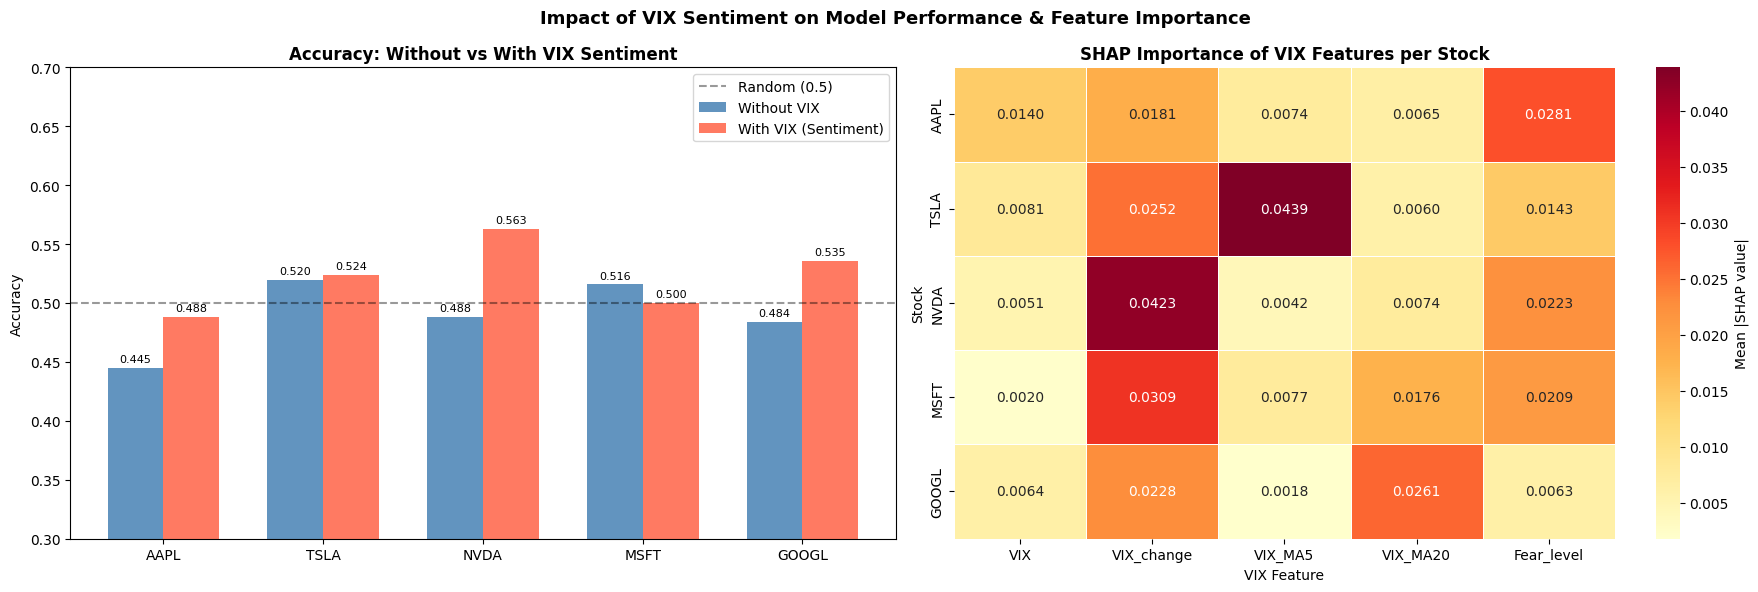

✅ Saved: vix_sentiment_analysis.png

=== Key Findings ===
VIX ช่วยเพิ่ม Accuracy: 4/5 หุ้น
NVDA ได้ประโยชน์สูงสุด: +0.0748
VIX_change มี SHAP สูงสุดใน NVDA และ MSFT
Fear_level มี SHAP สูงสุดใน AAPL


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Impact of VIX Sentiment on Model Performance & Feature Importance", 
             fontsize=13, fontweight="bold")

# --- Plot 1: Accuracy Before vs After VIX ---
vix_df_plot = pd.DataFrame(vix_comparison)
x = np.arange(len(TICKERS))
width = 0.35

bars1 = axes[0].bar(x - width/2, vix_df_plot["Without_VIX"], width, 
                     label="Without VIX", color="steelblue", alpha=0.85)
bars2 = axes[0].bar(x + width/2, vix_df_plot["With_VIX"], width, 
                     label="With VIX (Sentiment)", color="tomato", alpha=0.85)

axes[0].set_title("Accuracy: Without vs With VIX Sentiment", fontweight="bold")
axes[0].set_xticks(x)
axes[0].set_xticklabels(TICKERS)
axes[0].set_ylim(0.3, 0.7)
axes[0].axhline(y=0.5, color="black", linestyle="--", alpha=0.4, label="Random (0.5)")
axes[0].legend()
axes[0].set_ylabel("Accuracy")

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{bar.get_height():.3f}", ha="center", fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{bar.get_height():.3f}", ha="center", fontsize=8)

# --- Plot 2: VIX Feature SHAP Importance Heatmap ---
vix_shap_data = {
    "AAPL": [0.0140, 0.0181, 0.0074, 0.0065, 0.0281],
    "TSLA": [0.0081, 0.0252, 0.0439, 0.0060, 0.0143],
    "NVDA": [0.0051, 0.0423, 0.0042, 0.0074, 0.0223],
    "MSFT": [0.0020, 0.0309, 0.0077, 0.0176, 0.0209],
    "GOOGL": [0.0064, 0.0228, 0.0018, 0.0261, 0.0063],
}
vix_shap_df = pd.DataFrame(vix_shap_data, index=VIX_FEATURES).T

sns.heatmap(vix_shap_df, ax=axes[1], cmap="YlOrRd", annot=True, 
            fmt=".4f", linewidths=0.5,
            cbar_kws={"label": "Mean |SHAP value|"})
axes[1].set_title("SHAP Importance of VIX Features per Stock", fontweight="bold")
axes[1].set_xlabel("VIX Feature")
axes[1].set_ylabel("Stock")

plt.tight_layout()
plt.savefig("vix_sentiment_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: vix_sentiment_analysis.png")

# Summary
print("\n=== Key Findings ===")
print(f"VIX ช่วยเพิ่ม Accuracy: {sum(1 for v in vix_comparison if v['Diff'] > 0)}/5 หุ้น")
print(f"NVDA ได้ประโยชน์สูงสุด: +{max(v['Diff'] for v in vix_comparison):.4f}")
print(f"VIX_change มี SHAP สูงสุดใน NVDA และ MSFT")
print(f"Fear_level มี SHAP สูงสุดใน AAPL")